# Count Profile Stability

        ## Manuscript targets
        - `Methodology / Count-Profile Stability Evaluation`
- `Results / Impact of trimming on the technical level`
- `Figure Technical distribution (Spearman)`
- `Table count stability 1`

        ## Primary inputs
        - `share/results/technical/per_srr_eval.tsv`

        ## Rebuild scripts
        - `share/scripts/analysis/02_evaluate_featurecounts_matrix_similarity.py`
- `share/scripts/analysis/04_summarize_technical_analysis_outputs.py`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

Each SRR is compared with its own untrimmed baseline across trimmed modes. This notebook rebuilds the summary table used in the manuscript and visualizes the Spearman distribution that best exposes the technical spread across trimming settings.


In [1]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    # --- Standardized Plotting Configuration ---
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })
    sns.set_theme(style="whitegrid", palette="colorblind")
    plt.rcParams.update({"font.family": "sans-serif"})
    # -------------------------------------------
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [2]:
REBUILD = False
if REBUILD:
    run_script("share/scripts/analysis/02_evaluate_featurecounts_matrix_similarity.py")
    run_script("share/scripts/analysis/04_summarize_technical_analysis_outputs.py")

eval_df = load_table(TECH / "per_srr_eval.tsv")
eval_df.head()


,SRR_ID,project_id,untrmd_adptrTrmd_jsd,untrmd_P5Trmd_jsd,untrmd_P10Trmd_jsd,untrmd_P20Trmd_jsd,untrmd_P35Trmd_jsd,P5Trmd_P35Trmd_jsd,untrmd_adptrTrmd_pear,untrmd_P5Trmd_pear,untrmd_P10Trmd_pear,untrmd_P20Trmd_pear,untrmd_P35Trmd_pear,P5Trmd_P35Trmd_pear,untrmd_adptrTrmd_spear,untrmd_P5Trmd_spear,untrmd_P10Trmd_spear,untrmd_P20Trmd_spear,untrmd_P35Trmd_spear,P5Trmd_P35Trmd_spear,untrmd_adptrTrmd_cos,untrmd_P5Trmd_cos,untrmd_P10Trmd_cos,untrmd_P20Trmd_cos,untrmd_P35Trmd_cos,P5Trmd_P35Trmd_cos
0,SRR26067912,PRJNA1014106,0.000004,0.000004,0.000004,0.000098,0.005364,0.005292,0.999999,0.999999,0.999999,0.999987,0.996833,0.996895,0.999938,0.999937,0.999937,0.998822,0.941507,0.941848,0.999999,0.999999,0.999999,0.999987,0.996854,0.996916
1,SRR26067919,PRJNA1014106,0.000003,0.000003,0.000003,0.000096,0.005667,0.005603,0.999999,0.999999,0.999999,0.999986,0.995751,0.995804,0.999948,0.999947,0.999947,0.998657,0.932834,0.933053,0.999999,0.999999,0.999999,0.999987,0.995814,0.995867
2,SRR26067920,PRJNA1014106,0.000005,0.000005,0.000005,0.000094,0.005452,0.005373,0.999999,0.999999,0.999999,0.999987,0.997320,0.997372,0.999909,0.999908,0.999908,0.998726,0.941912,0.942374,0.999999,0.999999,0.999999,0.999988,0.997334,0.997385
3,SRR26067916,PRJNA1014106,0.000004,0.000004,0.000004,0.000004,NaN,NaN,0.999996,0.999996,0.999996,0.999996,NaN,NaN,0.999986,0.999986,0.999986,0.999986,NaN,NaN,0.999997,0.999997,0.999997,0.999997,NaN,NaN
4,SRR26067911,PRJNA1014106,0.000004,0.000004,0.000004,0.000138,0.006079,0.006016,0.999999,0.999999,0.999999,0.999988,0.995388,0.995424,0.999952,0.999952,0.999951,0.998767,0.943733,0.944122,0.999999,0.999999,0.999999,0.999988,0.995453,0.995489


In [3]:
metric_map = {
    "Adapter": {
        "pear": "untrmd_adptrTrmd_pear",
        "spear": "untrmd_adptrTrmd_spear",
        "cos": "untrmd_adptrTrmd_cos",
        "jsd": "untrmd_adptrTrmd_jsd",
    },
    "P5": {
        "pear": "untrmd_P5Trmd_pear",
        "spear": "untrmd_P5Trmd_spear",
        "cos": "untrmd_P5Trmd_cos",
        "jsd": "untrmd_P5Trmd_jsd",
    },
    "P10": {
        "pear": "untrmd_P10Trmd_pear",
        "spear": "untrmd_P10Trmd_spear",
        "cos": "untrmd_P10Trmd_cos",
        "jsd": "untrmd_P10Trmd_jsd",
    },
    "P20": {
        "pear": "untrmd_P20Trmd_pear",
        "spear": "untrmd_P20Trmd_spear",
        "cos": "untrmd_P20Trmd_cos",
        "jsd": "untrmd_P20Trmd_jsd",
    },
    "P35": {
        "pear": "untrmd_P35Trmd_pear",
        "spear": "untrmd_P35Trmd_spear",
        "cos": "untrmd_P35Trmd_cos",
        "jsd": "untrmd_P35Trmd_jsd",
    },
    "P5 vs P35": {
        "pear": "P5Trmd_P35Trmd_pear",
        "spear": "P5Trmd_P35Trmd_spear",
        "cos": "P5Trmd_P35Trmd_cos",
        "jsd": "P5Trmd_P35Trmd_jsd",
    },
}

table_rows = []
for method, cols in metric_map.items():
    for metric_name, col in cols.items():
        values = pd.to_numeric(eval_df[col], errors="coerce")
        table_rows.append(
            {
                "Method": method,
                "Measure": metric_name,
                "Mean": values.mean(),
                "Std": values.std(),
                "Median": values.median(),
                "Min": values.min(),
                "Max": values.max(),
                "N": values.notna().sum(),
            }
        )

stability_table = pd.DataFrame(table_rows)
display(stability_table)


,Method,Measure,Mean,Std,Median,Min,Max,N
0,Adapter,pear,0.991026,0.084554,1.000000,8.808811e-02,1.000000,1125
1,Adapter,spear,0.983772,0.079958,0.999983,2.788297e-01,1.000000,1125
2,Adapter,cos,0.984610,0.111999,1.000000,1.151473e-03,1.000000,1134
3,Adapter,jsd,0.014346,0.093064,0.000004,0.000000e+00,0.998699,1134
4,P5,pear,0.988190,0.089546,0.999998,8.800447e-02,1.000000,1125
5,P5,spear,0.983788,0.075032,0.999930,2.821137e-01,1.000000,1125
6,P5,cos,0.983375,0.112381,0.999998,1.180361e-03,1.000000,1134
7,P5,jsd,0.014858,0.092927,0.000011,0.000000e+00,0.998633,1134
8,P10,pear,0.987699,0.089236,0.999996,8.800380e-02,1.000000,1125
9,P10,spear,0.981273,0.079962,0.999851,2.821061e-01,1.000000,1125


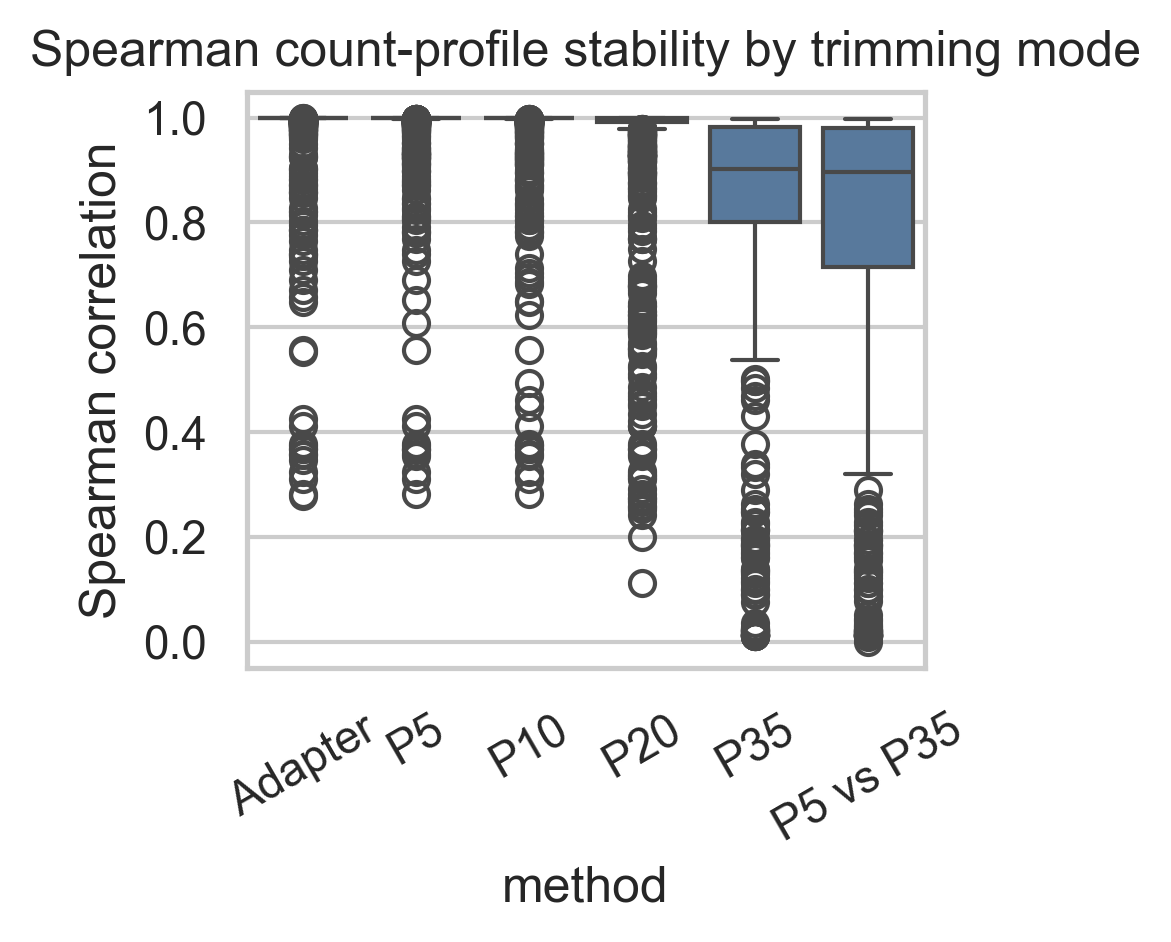

In [4]:
spear_cols = [
    ("Adapter", "untrmd_adptrTrmd_spear"),
    ("P5", "untrmd_P5Trmd_spear"),
    ("P10", "untrmd_P10Trmd_spear"),
    ("P20", "untrmd_P20Trmd_spear"),
    ("P35", "untrmd_P35Trmd_spear"),
    ("P5 vs P35", "P5Trmd_P35Trmd_spear"),
]

spear_data = [
    pd.to_numeric(eval_df[col], errors="coerce").dropna().to_numpy()
    for _, col in spear_cols
]

fig, ax = plt.subplots(figsize=(3.3, 3.3))
if sns is not None:
    plot_df = pd.concat(
        [
            pd.DataFrame({"method": method, "spearman": pd.to_numeric(eval_df[col], errors="coerce")})
            for method, col in spear_cols
        ],
        ignore_index=True,
    ).dropna()
    sns.boxplot(data=plot_df, x="method", y="spearman", ax=ax, color="#4C78A8")
else:
    ax.boxplot(spear_data, tick_labels=[label for label, _ in spear_cols])
ax.set_title("Spearman count-profile stability by trimming mode")
ax.set_ylabel("Spearman correlation")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
